# PSA LHS Manifest Visualization

This notebook visualizes the Latin Hypercube Sampling optimization results stored in `data/manifest.csv` for the four-step PSA workflow. It intentionally does **not** read `data/profiles/` in this version.

Outputs are saved as:

- PNG files for slides: `slide/pic/psa_manifest/`
- PDF files for reports: `report/figures/psa_manifest/`


In [2]:
from pathlib import Path
import math
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.colors import Normalize
from matplotlib.ticker import MaxNLocator
import yaml

warnings.filterwarnings("ignore", category=UserWarning)


def find_project_root() -> Path:
    """Find the repository root from either the repo or notebook directory."""
    cwd = Path.cwd().resolve()
    for candidate in [cwd, *cwd.parents]:
        if (candidate / "data" / "manifest.csv").exists() and (candidate / "data" / "ProcessConfig.yaml").exists():
            return candidate
    raise FileNotFoundError("Could not locate data/manifest.csv and data/ProcessConfig.yaml from the current working directory.")


PROJECT_ROOT = find_project_root()
DATA_DIR = PROJECT_ROOT / "data"
MANIFEST_PATH = DATA_DIR / "manifest.csv"
CONFIG_PATH = DATA_DIR / "ProcessConfig.yaml"
PNG_DIR = PROJECT_ROOT / "slide" / "pic" / "psa_manifest"
PDF_DIR = PROJECT_ROOT / "report" / "figures" / "psa_manifest"

for directory in (PNG_DIR, PDF_DIR):
    directory.mkdir(parents=True, exist_ok=True)

try:
    plt.style.use("seaborn-v0_8-whitegrid")
except OSError:
    plt.style.use("default")

plt.rcParams.update({
    "figure.dpi": 120,
    "savefig.dpi": 300,
    "font.size": 10,
    "axes.titlesize": 11,
    "axes.labelsize": 10,
    "legend.fontsize": 9,
    "xtick.labelsize": 8,
    "ytick.labelsize": 8,
    "axes.spines.top": False,
    "axes.spines.right": False,
})

print(f"Project root: {PROJECT_ROOT}")
print(f"Manifest: {MANIFEST_PATH}")
print(f"PNG output: {PNG_DIR}")
print(f"PDF output: {PDF_DIR}")
print("Profile CSV files are intentionally not read in this notebook.")


Project root: E:\courses\SEEN5320-Final-Project
Manifest: E:\courses\SEEN5320-Final-Project\data\manifest.csv
PNG output: E:\courses\SEEN5320-Final-Project\slide\pic\psa_manifest
PDF output: E:\courses\SEEN5320-Final-Project\report\figures\psa_manifest
Profile CSV files are intentionally not read in this notebook.


## Load Data and Metadata

Design variable labels and configured bounds are taken from `ProcessConfig.yaml`. The fallback bounds match the current config and keep the notebook usable if the YAML file is unavailable.

In [3]:
design_cols = [f"x{i}" for i in range(1, 8)]
possible_constraint_cols = [f"cons{i}" for i in range(1, 5)]
important_metric_cols = ["purity", "recovery", "productivity_mol_kg_h", "energy_kWh_ton"]
diagnostic_cols = ["runtime_s"]
kpi_cols = [*important_metric_cols, *diagnostic_cols]
objective_cols = ["purity", "recovery", "productivity_mol_kg_h", "energy_kWh_ton"]
objective_directions = {
    "purity": "max",
    "recovery": "max",
    "productivity_mol_kg_h": "max",
    "energy_kWh_ton": "min",
}

variable_meta = {
    "x1": {"label": "Adsorption pressure", "unit": "Pa", "short": "P_ads"},
    "x2": {"label": "Adsorption time", "unit": "s", "short": "t_ads"},
    "x3": {"label": "Light product reflux ratio", "unit": "-", "short": "R_L"},
    "x4": {"label": "Feed velocity", "unit": "m/s", "short": "v_feed"},
    "x5": {"label": "Purge pressure", "unit": "Pa", "short": "P_purge"},
    "x6": {"label": "Pressurization time", "unit": "s", "short": "t_press"},
    "x7": {"label": "Counter-current depressurization time", "unit": "s", "short": "t_depress"},
}

kpi_meta = {
    "purity": {"label": "CO2 purity", "unit": "-"},
    "recovery": {"label": "CO2 recovery", "unit": "-"},
    "productivity_mol_kg_h": {"label": "Productivity", "unit": "mol kg$^{-1}$ h$^{-1}$"},
    "energy_kWh_ton": {"label": "Specific energy", "unit": "kWh ton$^{-1}$"},
    "runtime_s": {"label": "Simulation runtime", "unit": "s"},
}

fallback_lb = [100000, 10, 0.0, 0.1, 10000, 0, 0]
fallback_ub = [1000000, 5000, 1.0, 1.0, 100000, 100, 100]

try:
    with CONFIG_PATH.open("r", encoding="utf-8") as f:
        config = yaml.safe_load(f)
    lb = config["optimization_settings"]["lb"]
    ub = config["optimization_settings"]["ub"]
except Exception as exc:
    print(f"Warning: failed to parse config bounds, using fallback bounds: {exc}")
    lb, ub = fallback_lb, fallback_ub

bounds = {col: (float(lo), float(hi)) for col, lo, hi in zip(design_cols, lb, ub)}

manifest = pd.read_csv(MANIFEST_PATH)
constraint_cols = [col for col in possible_constraint_cols if col in manifest.columns]
missing_constraint_cols = [col for col in possible_constraint_cols if col not in manifest.columns]
required_cols = ["sample_id", "status", *design_cols, *kpi_cols]
missing = [col for col in required_cols if col not in manifest.columns]
if missing:
    raise KeyError(f"Missing required columns in manifest.csv: {missing}")

numeric_cols = ["sample_id", *design_cols, *constraint_cols, *kpi_cols]
for col in numeric_cols:
    if col in manifest.columns:
        manifest[col] = pd.to_numeric(manifest[col], errors="coerce")

success = manifest.loc[manifest["status"].eq("success")].copy()
if success.empty:
    raise ValueError("No successful samples found in manifest.csv")

print(f"Total samples: {len(manifest):,}")
print(f"Successful samples used for analysis: {len(success):,}")
print(f"Failed/non-success samples excluded: {len(manifest) - len(success):,}")
if missing_constraint_cols:
    print(f"Constraint columns not present and skipped: {missing_constraint_cols}")

summary_cols = [*design_cols, *kpi_cols, *constraint_cols]
summary = success[summary_cols].describe().T
summary[["min", "mean", "50%", "max"]]


Total samples: 1,000
Successful samples used for analysis: 1,000
Failed/non-success samples excluded: 0
Constraint columns not present and skipped: ['cons1', 'cons2', 'cons3', 'cons4']


,min,mean,50%,max
x1,100747.217885,549993.684425,550225.809852,999805.892363
x2,12.332805,2505.048029,2504.809473,4998.027656
x3,0.000353,0.500002,0.499985,0.999109
x4,0.100450,0.550016,0.550133,0.999979
x5,10068.031488,54999.527361,54991.008252,99988.994015
x6,0.060587,50.000638,50.013997,99.995764
x7,0.097199,50.000901,50.000320,99.981076
purity,0.150002,0.169590,0.155159,0.669704
recovery,0.005555,0.532625,0.539811,1.000000
productivity_mol_kg_h,0.243271,22.454533,14.916602,115.449603


In [4]:
def axis_label(col: str) -> str:
    if col in variable_meta:
        item = variable_meta[col]
        unit = item["unit"]
        return f"{item['label']} [{unit}]" if unit != "-" else f"{item['label']} [-]"
    if col in kpi_meta:
        item = kpi_meta[col]
        unit = item["unit"]
        return f"{item['label']} [{unit}]" if unit != "-" else f"{item['label']} [-]"
    return col


def short_label(col: str) -> str:
    if col in variable_meta:
        return variable_meta[col]["short"]
    if col in kpi_meta:
        return kpi_meta[col]["label"]
    return col


def save_figure(fig: plt.Figure, name: str) -> None:
    png_path = PNG_DIR / f"{name}.png"
    pdf_path = PDF_DIR / f"{name}.pdf"
    fig.savefig(png_path, bbox_inches="tight", dpi=300)
    fig.savefig(pdf_path, bbox_inches="tight")
    print(f"Saved {png_path.relative_to(PROJECT_ROOT)}")
    print(f"Saved {pdf_path.relative_to(PROJECT_ROOT)}")


def minmax_scale(series: pd.Series) -> pd.Series:
    series = pd.to_numeric(series, errors="coerce")
    span = series.max() - series.min()
    if pd.isna(span) or span == 0:
        return pd.Series(np.zeros(len(series)), index=series.index)
    return (series - series.min()) / span


def pareto_front_mask(df: pd.DataFrame, objective_directions: dict[str, str]) -> np.ndarray:
    """Return non-dominated points after converting every objective to higher-is-better."""
    objectives = list(objective_directions)
    signs = np.array([1.0 if objective_directions[col] == "max" else -1.0 for col in objectives])
    scores = df[objectives].to_numpy(dtype=float) * signs
    valid = np.isfinite(scores).all(axis=1)
    mask = np.zeros(len(df), dtype=bool)

    for i in np.where(valid)[0]:
        dominated_by_any = np.any(
            valid
            & np.all(scores >= scores[i], axis=1)
            & np.any(scores > scores[i], axis=1)
        )
        mask[i] = not dominated_by_any
    return mask


analysis = success.dropna(subset=[*design_cols, *kpi_cols]).copy()
analysis["is_pareto"] = pareto_front_mask(analysis, objective_directions)
analysis["log_energy"] = np.log10(analysis["energy_kWh_ton"].clip(lower=1e-12))
analysis["balanced_score"] = (
    minmax_scale(analysis["productivity_mol_kg_h"])
    + minmax_scale(analysis["purity"])
    + minmax_scale(analysis["recovery"])
    + (1 - minmax_scale(analysis["log_energy"]))
)

print(f"Rows available after numeric KPI/design cleanup: {len(analysis):,}")
print("Pareto objectives:")
for col, direction in objective_directions.items():
    print(f"  {direction.upper():>3} {axis_label(col)}")
print(f"Four-objective Pareto-front samples: {int(analysis['is_pareto'].sum()):,}")
print(f"Purity-recovery Spearman rho: {analysis[['purity', 'recovery']].corr(method='spearman').iloc[0, 1]:.3f}")


Rows available after numeric KPI/design cleanup: 1,000
Pareto objectives:
  MAX CO2 purity [-]
  MAX CO2 recovery [-]
  MAX Productivity [mol kg$^{-1}$ h$^{-1}$]
  MIN Specific energy [kWh ton$^{-1}$]
Four-objective Pareto-front samples: 138
Purity-recovery Spearman rho: -0.691


## Sampling Coverage

Histograms check whether each LHS variable spans its configured interval. Dashed lines mark the lower and upper bounds from `ProcessConfig.yaml`.

Saved slide\pic\psa_manifest\01_sampling_coverage_histograms.png
Saved report\figures\psa_manifest\01_sampling_coverage_histograms.pdf


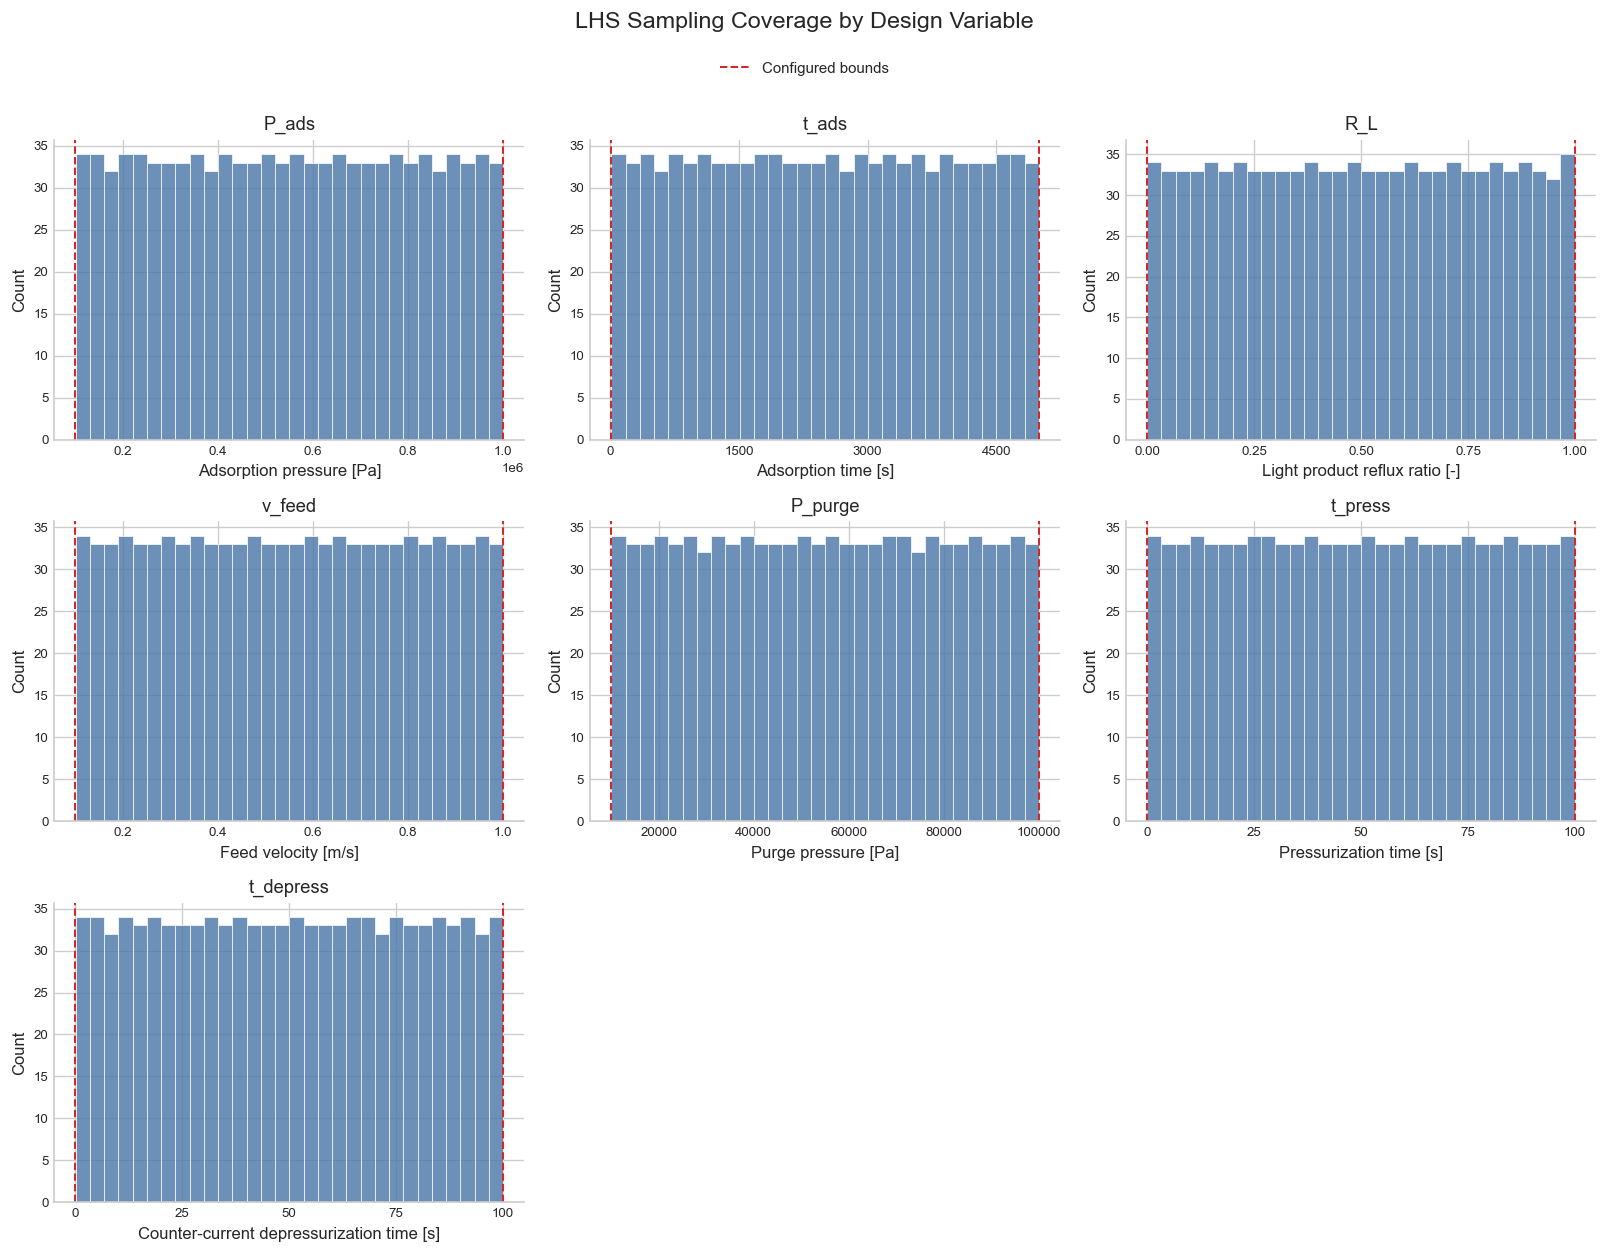

In [5]:
fig, axes = plt.subplots(3, 3, figsize=(13.5, 10))
axes = axes.ravel()

for ax, col in zip(axes, design_cols):
    values = analysis[col].dropna()
    lo, hi = bounds[col]
    ax.hist(values, bins=30, color="#4C78A8", alpha=0.82, edgecolor="white", linewidth=0.5)
    ax.axvline(lo, color="#D62728", linestyle="--", linewidth=1.2, label="Configured bounds")
    ax.axvline(hi, color="#D62728", linestyle="--", linewidth=1.2)
    ax.set_title(f"{short_label(col)}")
    ax.set_xlabel(axis_label(col))
    ax.set_ylabel("Count")
    ax.xaxis.set_major_locator(MaxNLocator(nbins=5))

for ax in axes[len(design_cols):]:
    ax.axis("off")

handles, labels = axes[0].get_legend_handles_labels()
fig.legend(handles, labels, loc="upper center", ncol=1, frameon=False, bbox_to_anchor=(0.5, 1.01))
fig.suptitle("LHS Sampling Coverage by Design Variable", y=1.04, fontsize=14)
fig.tight_layout()
save_figure(fig, "01_sampling_coverage_histograms")
plt.show()


## LHS Pair Matrix

The diagonal panels show marginal distributions. Lower-triangle panels show pairwise samples. Upper-triangle panels show Spearman rank correlations, where values near zero are expected for well-spread independent LHS variables.

Saved slide\pic\psa_manifest\02_lhs_pair_matrix.png
Saved report\figures\psa_manifest\02_lhs_pair_matrix.pdf


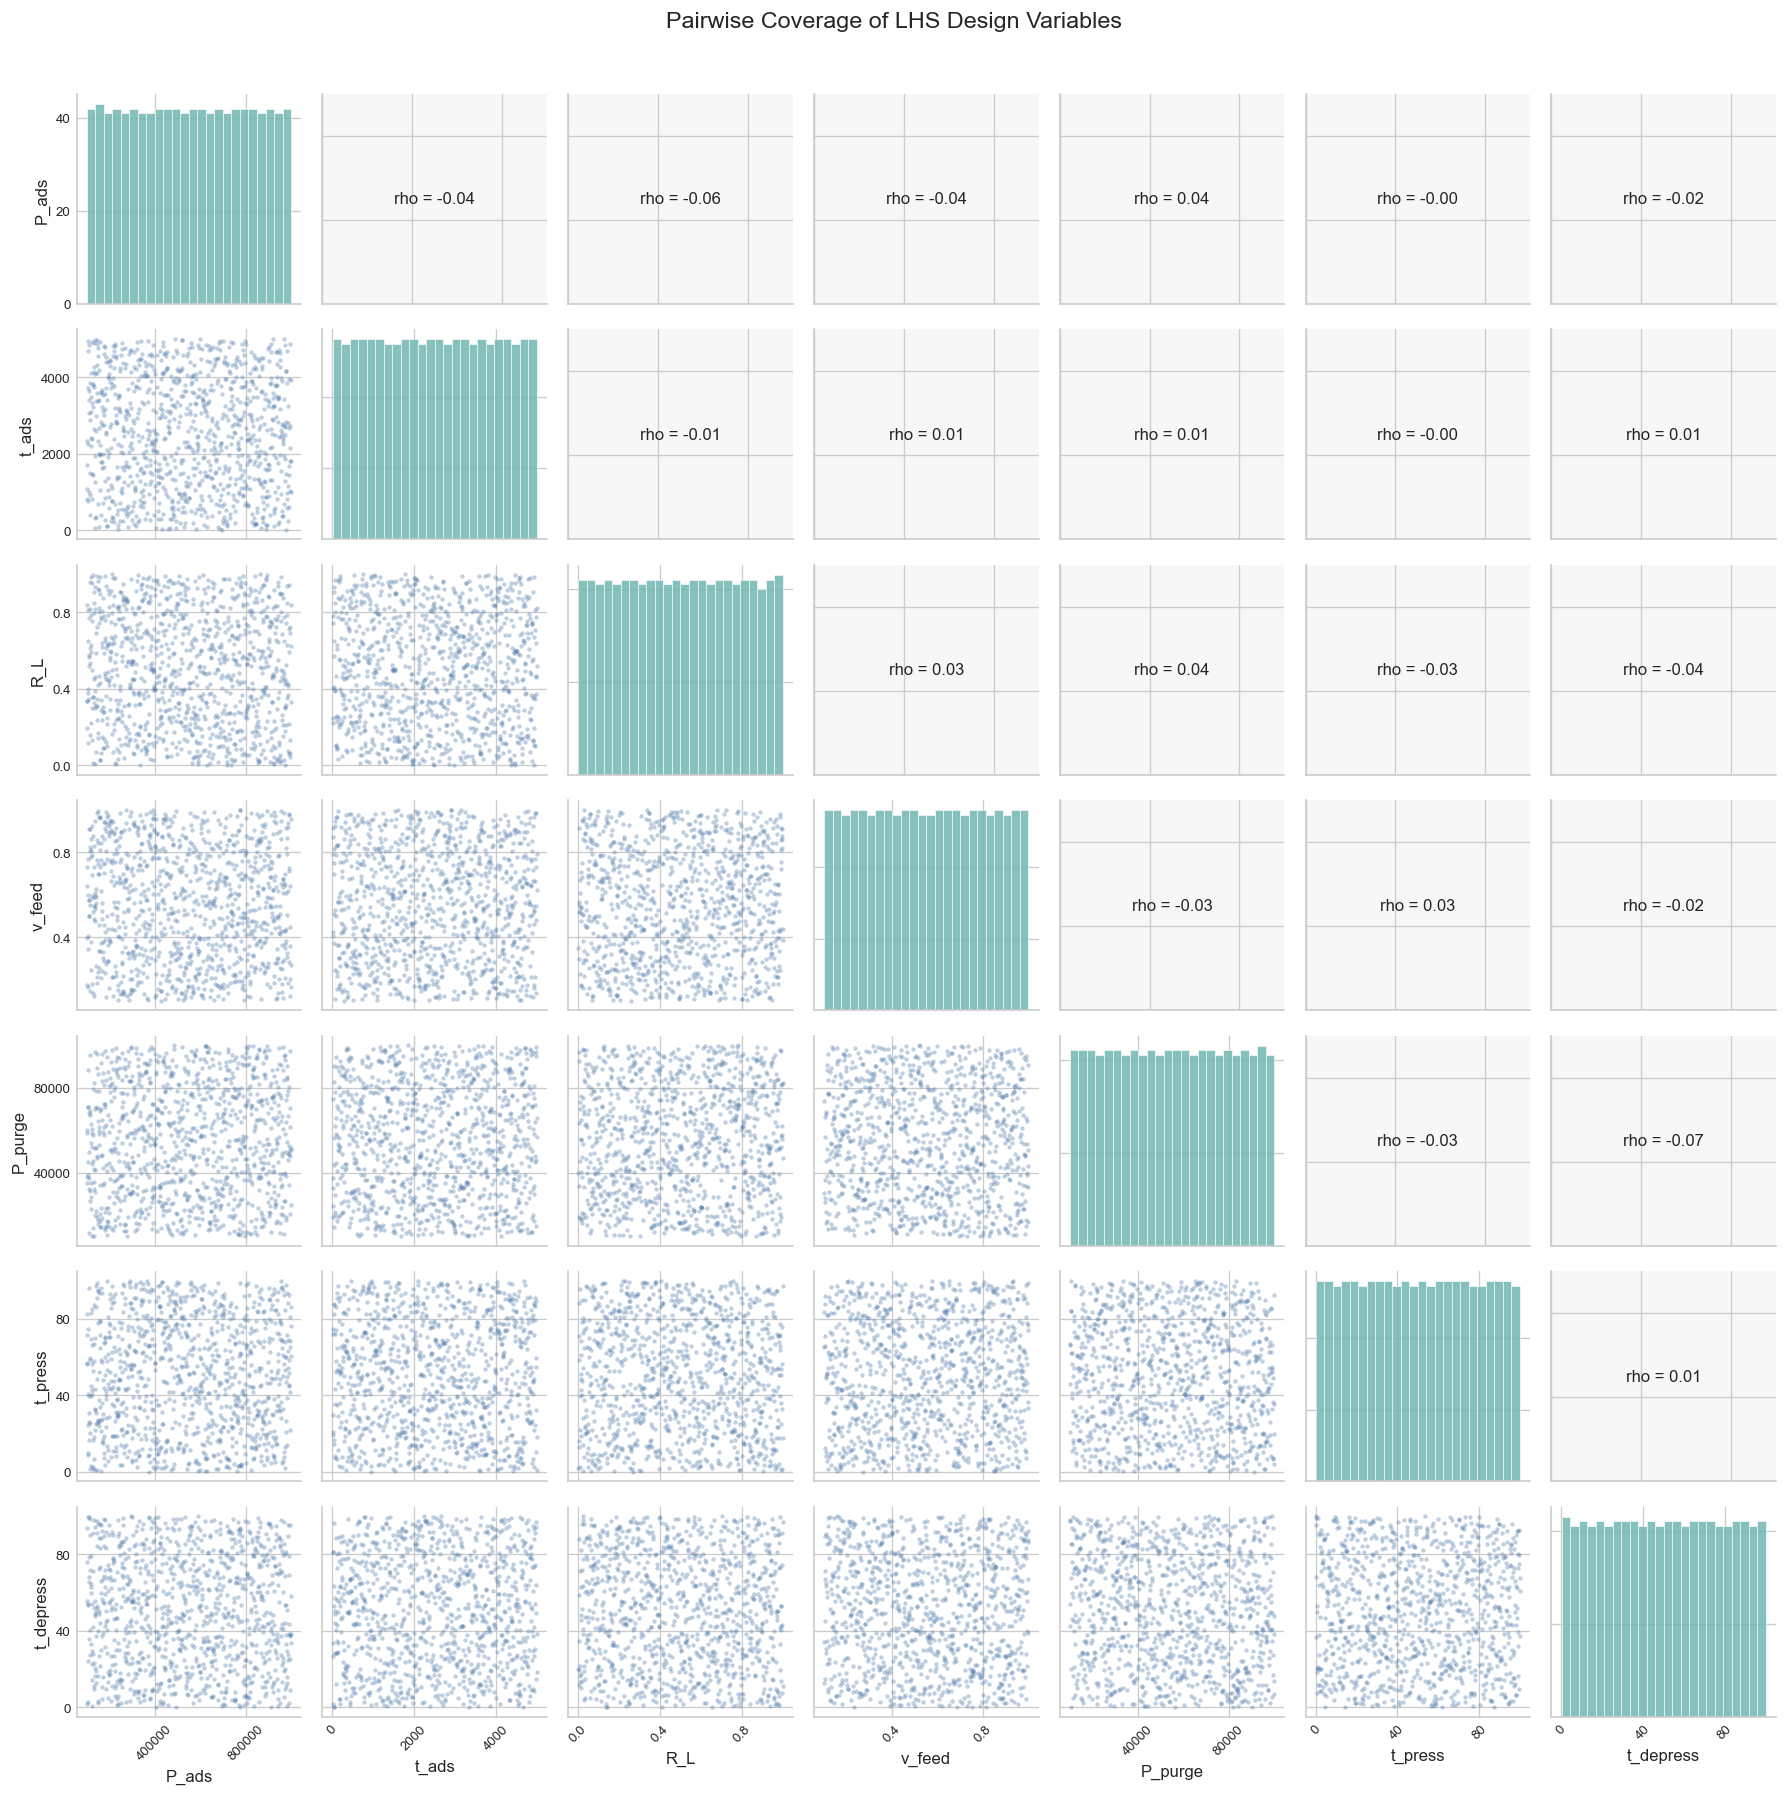

In [6]:
pair_corr = analysis[design_cols].corr(method="spearman")
n = len(design_cols)
fig, axes = plt.subplots(n, n, figsize=(15, 15))

for i, row_col in enumerate(design_cols):
    for j, col_col in enumerate(design_cols):
        ax = axes[i, j]
        if i == j:
            ax.hist(analysis[col_col], bins=24, color="#72B7B2", alpha=0.85, edgecolor="white", linewidth=0.4)
        elif i > j:
            ax.scatter(analysis[col_col], analysis[row_col], s=7, alpha=0.35, color="#4C78A8", linewidth=0)
        else:
            rho = pair_corr.loc[row_col, col_col]
            ax.text(0.5, 0.5, f"rho = {rho:.2f}", ha="center", va="center", transform=ax.transAxes, fontsize=10)
            ax.set_facecolor("#F7F7F7")
        if i < n - 1:
            ax.set_xticklabels([])
        else:
            ax.set_xlabel(short_label(col_col))
            ax.tick_params(axis="x", rotation=45)
        if j > 0:
            ax.set_yticklabels([])
        else:
            ax.set_ylabel(short_label(row_col))
        ax.xaxis.set_major_locator(MaxNLocator(nbins=3))
        ax.yaxis.set_major_locator(MaxNLocator(nbins=3))

fig.suptitle("Pairwise Coverage of LHS Design Variables", y=0.995, fontsize=14)
fig.tight_layout(rect=[0, 0, 1, 0.98])
save_figure(fig, "02_lhs_pair_matrix")
plt.show()


## Four Key Output Metric Scatter Matrix

This scatter matrix shows the pairwise relationships among the four important PSA performance metrics. Diagonal panels show each metric distribution; off-diagonal panels show pairwise scatter with Pareto-front samples highlighted.

Saved slide\pic\psa_manifest\03_kpi_distributions.png
Saved report\figures\psa_manifest\03_kpi_distributions.pdf


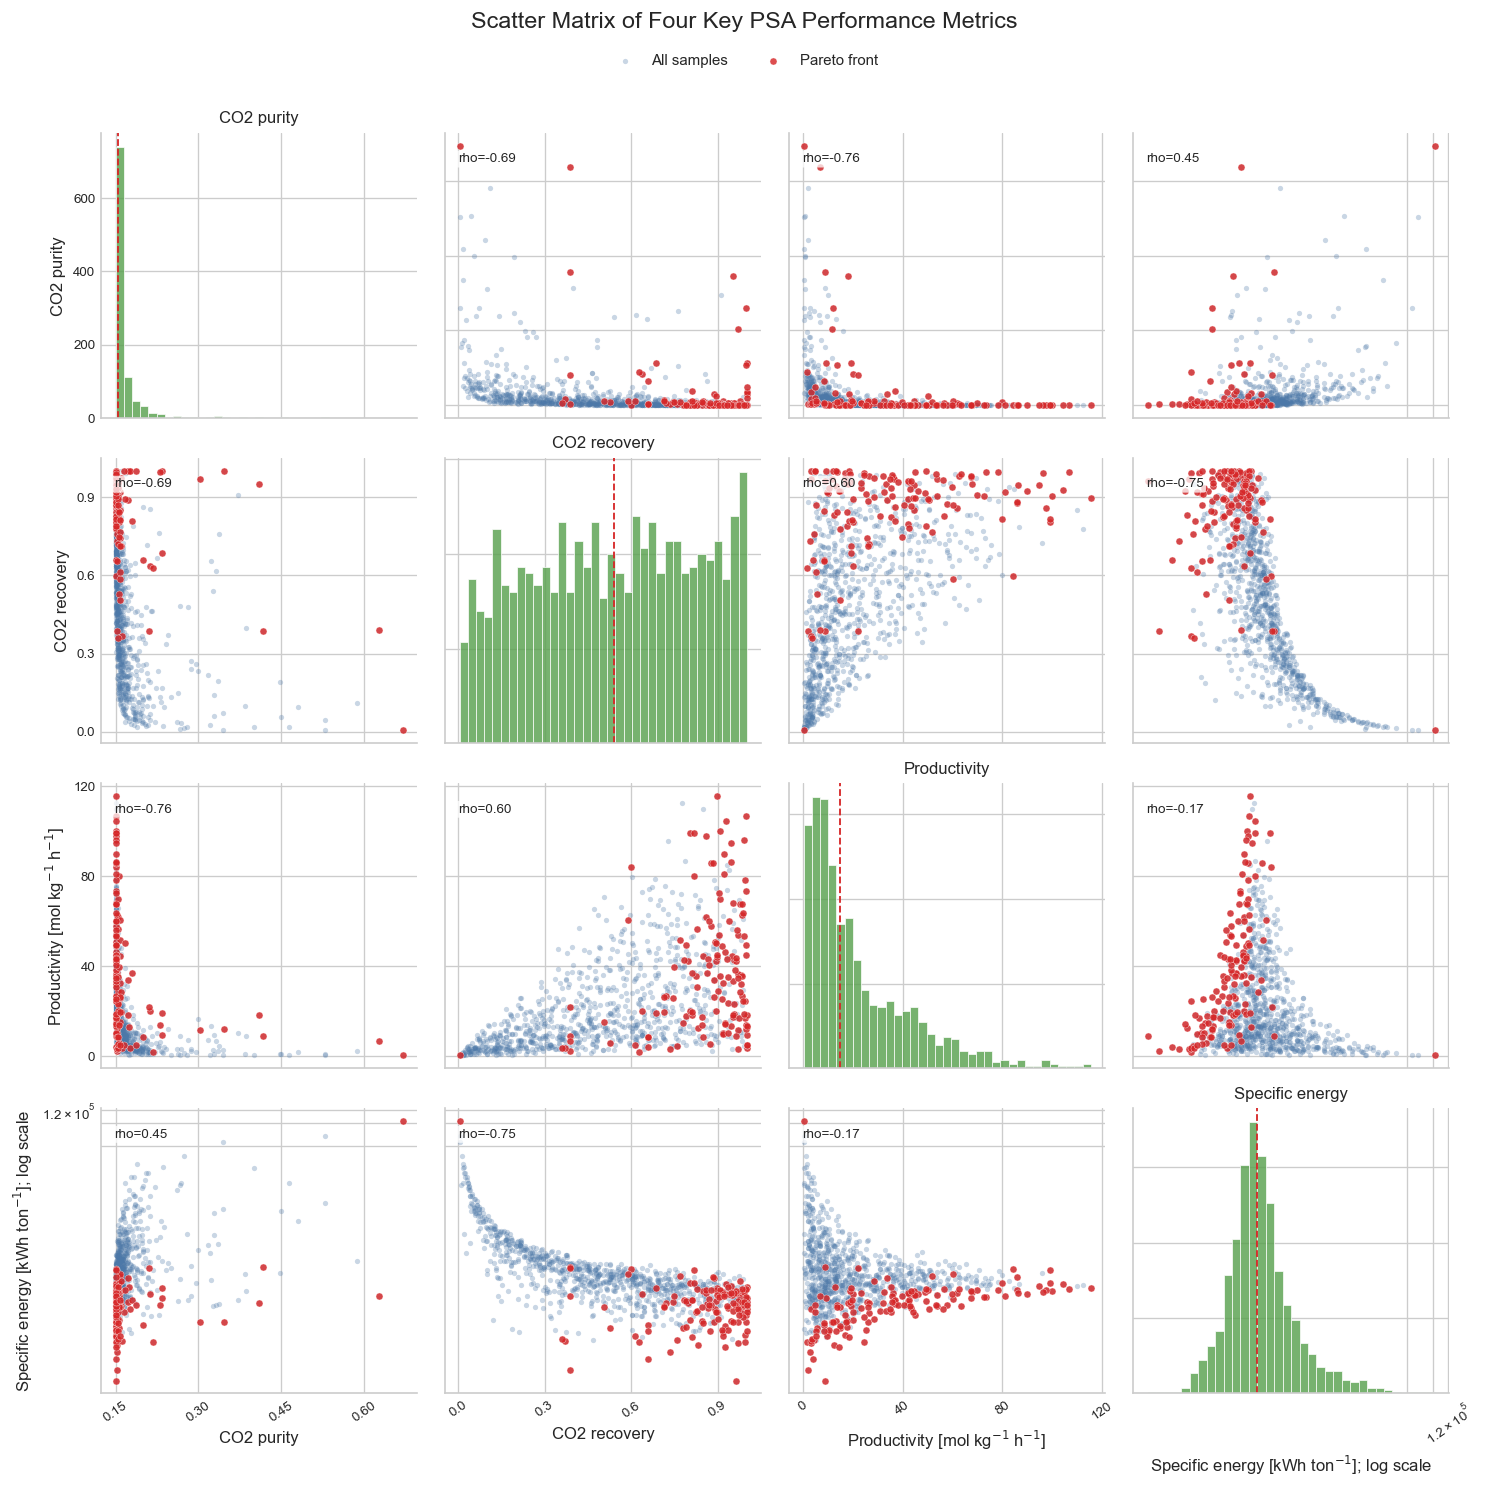

,min,mean,50%,max
purity,0.150002,0.169590,0.155159,0.669704
recovery,0.005555,0.532625,0.539811,1.000000
productivity_mol_kg_h,0.243271,22.454533,14.916602,115.449603
energy_kWh_ton,36.699019,1538.733190,696.383191,84378.804286


In [7]:
metric_cols = important_metric_cols
metric_labels = [kpi_meta[col]["label"] for col in metric_cols]
metric_units = [kpi_meta[col]["unit"] for col in metric_cols]
n_metrics = len(metric_cols)

fig, axes = plt.subplots(n_metrics, n_metrics, figsize=(12.5, 12.0))
pareto_mask = analysis["is_pareto"].to_numpy(dtype=bool)

for i, ycol in enumerate(metric_cols):
    for j, xcol in enumerate(metric_cols):
        ax = axes[i, j]
        x = analysis[xcol]
        y = analysis[ycol]

        if i == j:
            values = analysis[xcol].dropna()
            if xcol == "energy_kWh_ton" and values.min() > 0:
                bins = np.logspace(np.log10(values.min()), np.log10(values.max()), 35)
                ax.hist(values, bins=bins, color="#59A14F", alpha=0.82, edgecolor="white", linewidth=0.5)
                ax.set_xscale("log")
            else:
                ax.hist(values, bins=35, color="#59A14F", alpha=0.82, edgecolor="white", linewidth=0.5)
            ax.axvline(values.median(), color="#D62728", linestyle="--", linewidth=1.1)
            ax.set_title(metric_labels[j], fontsize=10)
        else:
            ax.scatter(x, y, s=10, alpha=0.30, color="#4C78A8", linewidth=0, label="All samples")
            if pareto_mask.any():
                ax.scatter(
                    x.loc[pareto_mask],
                    y.loc[pareto_mask],
                    s=18,
                    alpha=0.82,
                    color="#D62728",
                    edgecolor="white",
                    linewidth=0.25,
                    label="Pareto front",
                )
            rho = analysis[[xcol, ycol]].corr(method="spearman").iloc[0, 1]
            ax.text(
                0.04,
                0.93,
                f"rho={rho:.2f}",
                transform=ax.transAxes,
                ha="left",
                va="top",
                fontsize=8,
                bbox={"boxstyle": "round,pad=0.18", "facecolor": "white", "edgecolor": "none", "alpha": 0.75},
            )
            if xcol == "energy_kWh_ton" and x.min() > 0:
                ax.set_xscale("log")
            if ycol == "energy_kWh_ton" and y.min() > 0:
                ax.set_yscale("log")

        if i == n_metrics - 1:
            x_unit = metric_units[j]
            xlabel = metric_labels[j] if x_unit == "-" else f"{metric_labels[j]} [{x_unit}]"
            if xcol == "energy_kWh_ton":
                xlabel = f"{xlabel}; log scale"
            ax.set_xlabel(xlabel)
            ax.tick_params(axis="x", rotation=35)
        else:
            ax.set_xticklabels([])

        if j == 0:
            y_unit = metric_units[i]
            ylabel = metric_labels[i] if y_unit == "-" else f"{metric_labels[i]} [{y_unit}]"
            if ycol == "energy_kWh_ton":
                ylabel = f"{ylabel}; log scale"
            ax.set_ylabel(ylabel)
        else:
            ax.set_yticklabels([])

        ax.xaxis.set_major_locator(MaxNLocator(nbins=4))
        ax.yaxis.set_major_locator(MaxNLocator(nbins=4))

handles, labels = axes[0, 1].get_legend_handles_labels()
if handles:
    fig.legend(handles, labels, loc="upper center", frameon=False, ncol=2, bbox_to_anchor=(0.5, 1.01))
fig.suptitle("Scatter Matrix of Four Key PSA Performance Metrics", y=1.03, fontsize=14)
fig.tight_layout()
save_figure(fig, "03_kpi_distributions")
plt.show()

analysis[metric_cols].describe().T[["min", "mean", "50%", "max"]]


## Objective Tradeoff Projection

The Pareto front is now computed with four objectives: maximize purity, maximize recovery, maximize productivity, and minimize specific energy. This plot projects that four-objective non-dominated set onto the productivity-energy plane; color still encodes purity and marker size encodes recovery.

In [ ]:
fig, ax = plt.subplots(figsize=(9.5, 6.5))

sizes = 25 + 130 * minmax_scale(analysis["recovery"])
scatter = ax.scatter(
    analysis["energy_kWh_ton"],
    analysis["productivity_mol_kg_h"],
    c=analysis["purity"],
    s=sizes,
    cmap="viridis",
    alpha=0.58,
    edgecolor="white",
    linewidth=0.25,
    label="Successful sample",
)

pareto = analysis.loc[analysis["is_pareto"]].sort_values("balanced_score", ascending=False)
ax.scatter(
    pareto["energy_kWh_ton"],
    pareto["productivity_mol_kg_h"],
    facecolor="none",
    edgecolor="#D62728",
    s=70,
    linewidth=1.1,
    zorder=5,
    label="4-objective Pareto set",
)

ax.set_xscale("log")
ax.set_xlabel("Specific energy [kWh ton$^{-1}$]; log scale")
ax.set_ylabel("Productivity [mol kg$^{-1}$ h$^{-1}$]")
ax.set_title("Four-Objective Pareto Set Projected onto Productivity-Energy Plane")
colorbar = fig.colorbar(scatter, ax=ax)
colorbar.set_label("CO2 purity [-]")

legend_sizes = [0.25, 0.50, 0.75]
legend_handles = [
    plt.scatter([], [], s=25 + 130 * value, color="#888888", alpha=0.55, edgecolor="white", linewidth=0.3)
    for value in legend_sizes
]
legend_labels = [f"Recovery ~ {value:.2f}" for value in legend_sizes]
first_legend = ax.legend(legend_handles, legend_labels, title="Marker size", loc="upper right", frameon=True)
ax.add_artist(first_legend)
ax.legend(loc="lower left", frameon=True)
fig.tight_layout()
save_figure(fig, "04_objective_tradeoff_pareto")
plt.show()

pareto[["sample_id", "purity", "recovery", "productivity_mol_kg_h", "energy_kWh_ton", "balanced_score"]].head(20)


## Input-Output Correlation Coefficient Distribution

This focused view uses Spearman rank correlations between the seven input variables and the four important output metrics. The heatmap shows direction and magnitude; the box/strip panel shows the coefficient distribution for each output metric.

Saved slide\pic\psa_manifest\05_input_output_correlation_distribution.png
Saved report\figures\psa_manifest\05_input_output_correlation_distribution.pdf


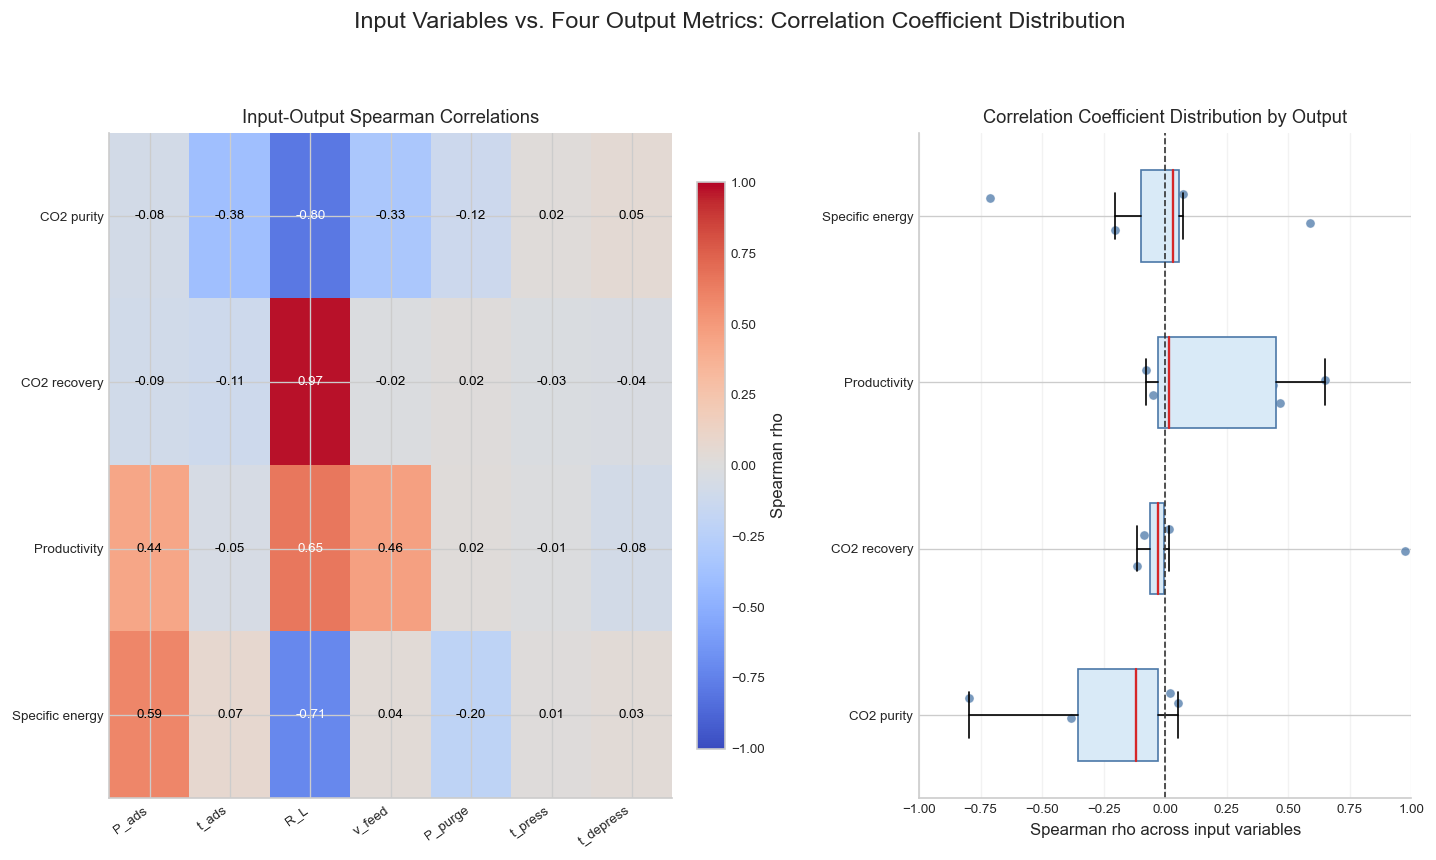

,input_variable,output_metric,spearman_rho,abs_rho
9,x3,recovery,0.971815,0.971815
8,x3,purity,-0.795325,0.795325
11,x3,energy_kWh_ton,-0.712230,0.712230
10,x3,productivity_mol_kg_h,0.648617,0.648617
3,x1,energy_kWh_ton,0.589305,0.589305
14,x4,productivity_mol_kg_h,0.464576,0.464576
2,x1,productivity_mol_kg_h,0.436549,0.436549
4,x2,purity,-0.383638,0.383638
12,x4,purity,-0.328060,0.328060
19,x5,energy_kWh_ton,-0.204788,0.204788


In [ ]:
io_corr = analysis[[*design_cols, *important_metric_cols]].corr(method="spearman").loc[design_cols, important_metric_cols]
long_corr = (
    io_corr.stack()
    .rename("spearman_rho")
    .reset_index()
    .rename(columns={"level_0": "input_variable", "level_1": "output_metric"})
)
long_corr["abs_rho"] = long_corr["spearman_rho"].abs()

fig = plt.figure(figsize=(14, 7.2))
gs = fig.add_gridspec(1, 2, width_ratios=[1.25, 1.0], wspace=0.35)

ax0 = fig.add_subplot(gs[0, 0])
heatmap_data = io_corr.T
im = ax0.imshow(heatmap_data, vmin=-1, vmax=1, cmap="coolwarm", aspect="auto")
ax0.set_xticks(np.arange(len(design_cols)))
ax0.set_xticklabels([short_label(col) for col in design_cols], rotation=35, ha="right")
ax0.set_yticks(np.arange(len(important_metric_cols)))
ax0.set_yticklabels([kpi_meta[col]["label"] for col in important_metric_cols])
ax0.set_title("Input-Output Spearman Correlations")

for i, metric in enumerate(important_metric_cols):
    for j, xcol in enumerate(design_cols):
        value = heatmap_data.loc[metric, xcol]
        text_color = "white" if abs(value) > 0.62 else "black"
        ax0.text(j, i, f"{value:.2f}", ha="center", va="center", fontsize=8, color=text_color)

colorbar = fig.colorbar(im, ax=ax0, fraction=0.046, pad=0.04)
colorbar.set_label("Spearman rho")

ax1 = fig.add_subplot(gs[0, 1])
metric_positions = np.arange(1, len(important_metric_cols) + 1)
metric_labels = [kpi_meta[col]["label"] for col in important_metric_cols]
box_data = [long_corr.loc[long_corr["output_metric"].eq(metric), "spearman_rho"].to_numpy() for metric in important_metric_cols]

box = ax1.boxplot(
    box_data,
    vert=False,
    positions=metric_positions,
    widths=0.55,
    patch_artist=True,
    showfliers=False,
)
for patch in box["boxes"]:
    patch.set_facecolor("#D9EAF7")
    patch.set_edgecolor("#4C78A8")
for median in box["medians"]:
    median.set_color("#D62728")
    median.set_linewidth(1.4)

rng = np.random.default_rng(42)
for pos, metric in zip(metric_positions, important_metric_cols):
    vals = long_corr.loc[long_corr["output_metric"].eq(metric), "spearman_rho"].to_numpy()
    y = pos + rng.uniform(-0.14, 0.14, size=len(vals))
    ax1.scatter(vals, y, s=30, alpha=0.75, color="#4C78A8", edgecolor="white", linewidth=0.3)

ax1.axvline(0, color="#333333", linestyle="--", linewidth=1.0)
ax1.set_xlim(-1, 1)
ax1.set_yticks(metric_positions)
ax1.set_yticklabels(metric_labels)
ax1.set_xlabel("Spearman rho across input variables")
ax1.set_title("Correlation Coefficient Distribution by Output")
ax1.grid(axis="x", alpha=0.25)

fig.suptitle("Input Variables vs. Four Output Metrics: Correlation Coefficient Distribution", y=1.02, fontsize=14)
fig.tight_layout()
save_figure(fig, "05_input_output_correlation_distribution")
plt.show()

long_corr.sort_values("abs_rho", ascending=False).head(12)


## Sensitivity Panels

Each panel compares a design variable with a KPI. The panel title gives the Spearman rank correlation for quick screening.

Saved slide\pic\psa_manifest\06_design_variable_sensitivity_panels.png
Saved report\figures\psa_manifest\06_design_variable_sensitivity_panels.pdf


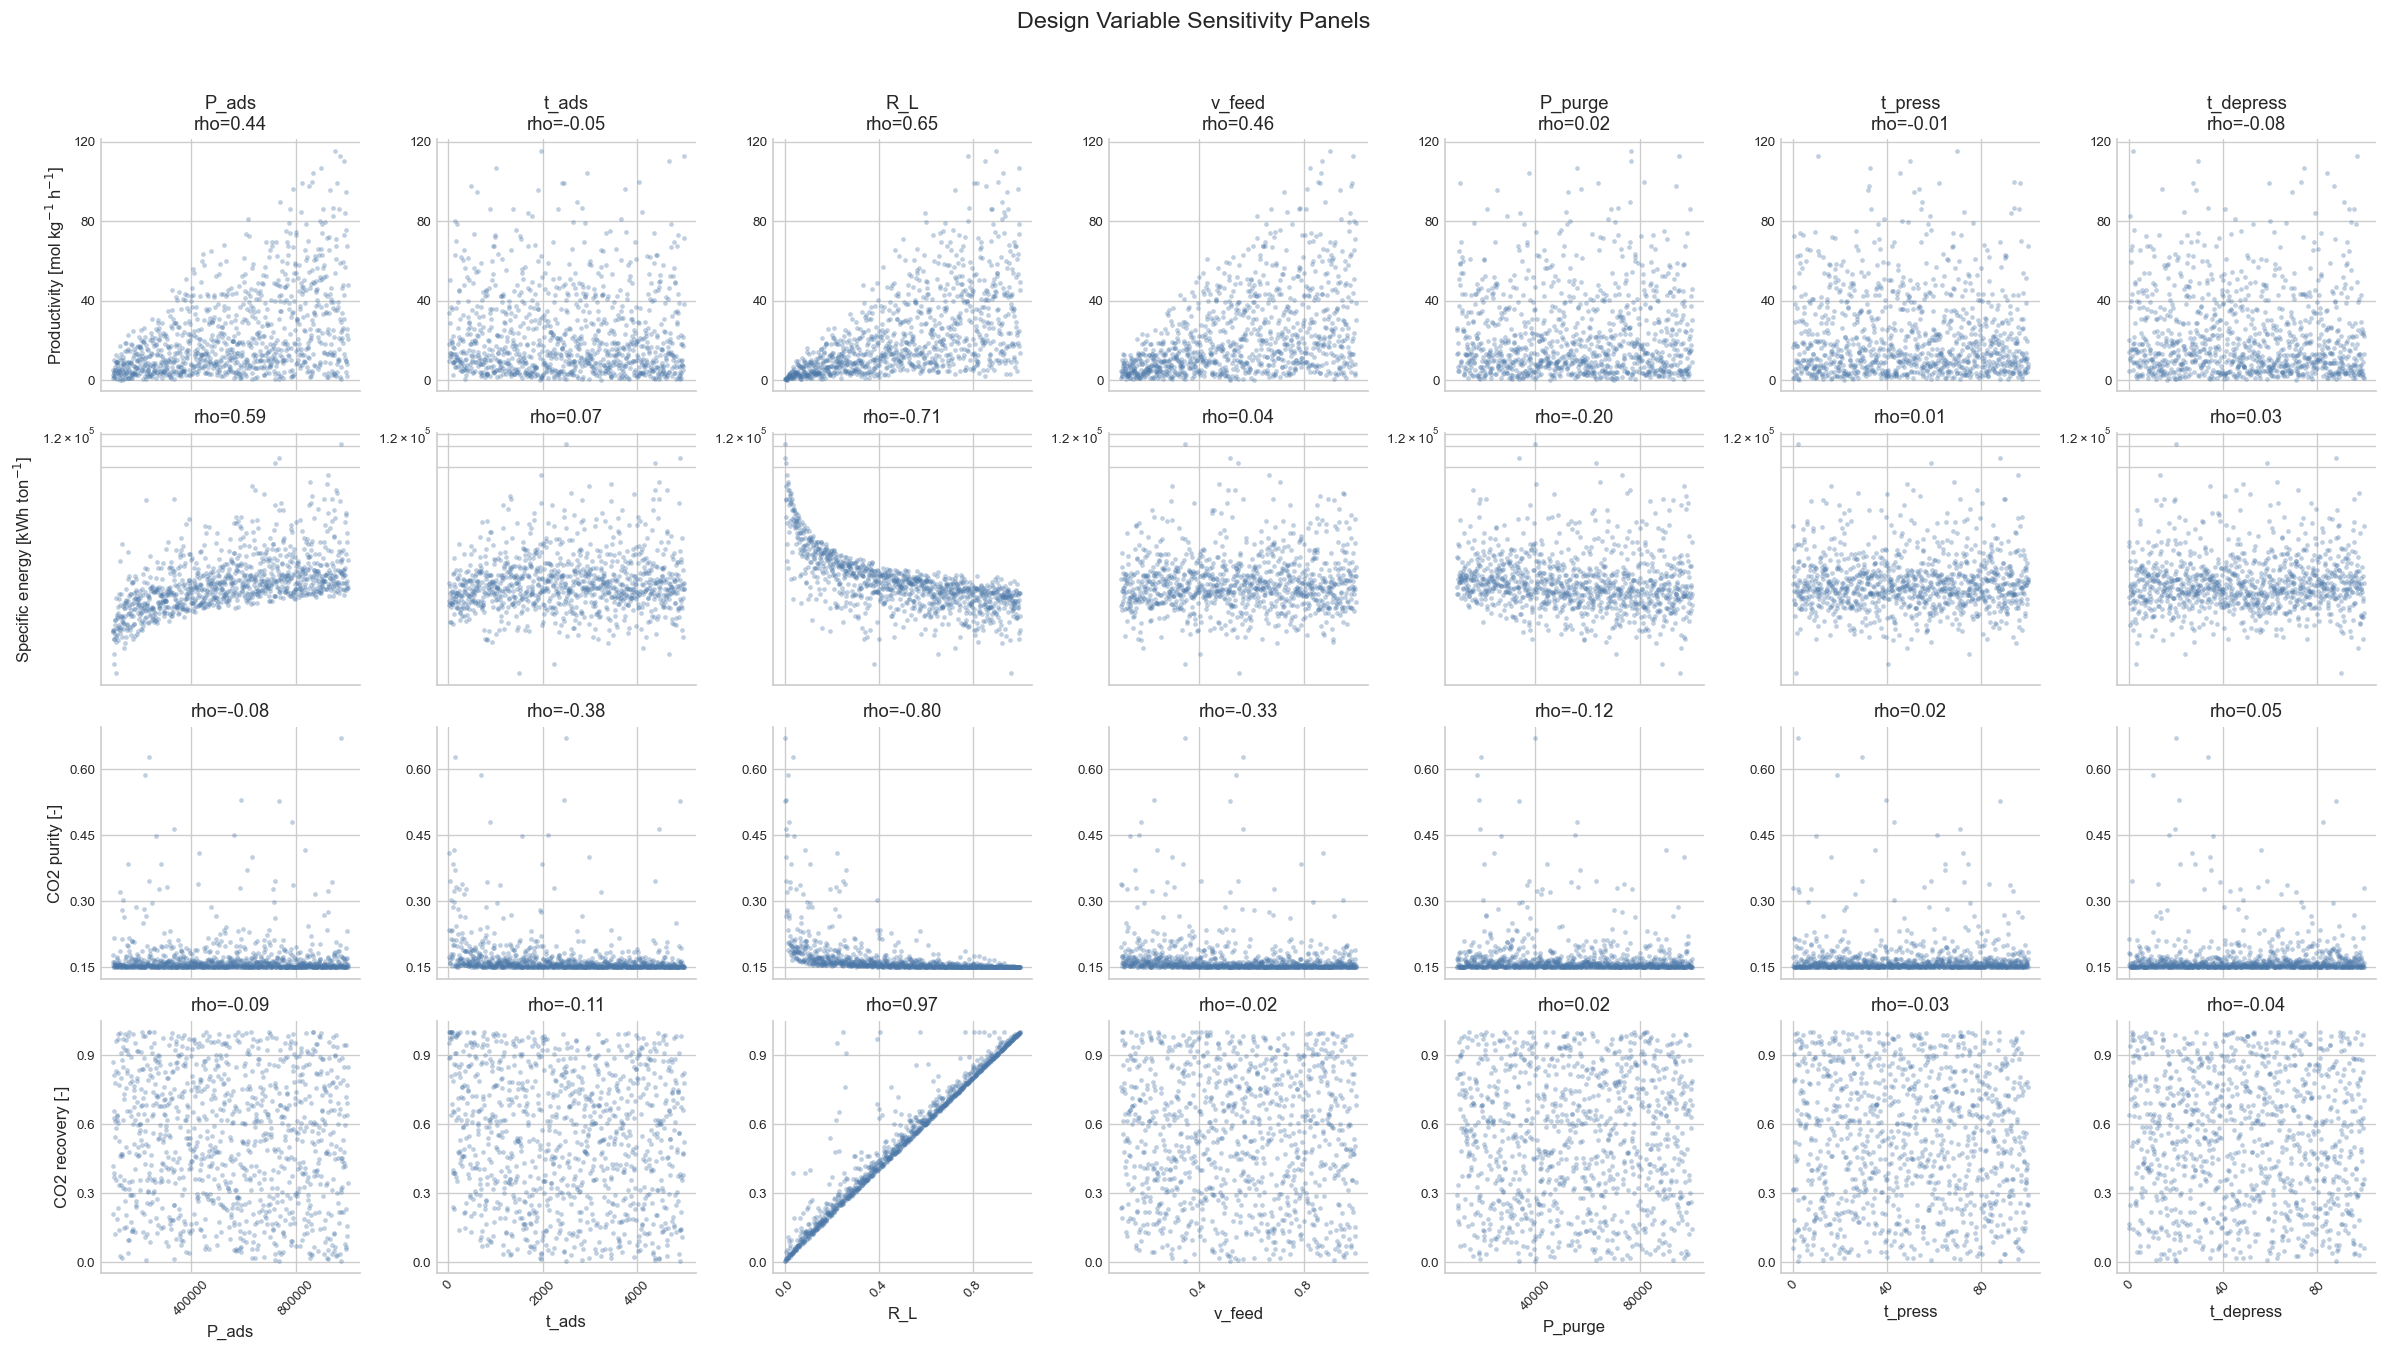

In [ ]:
sensitivity_kpis = ["productivity_mol_kg_h", "energy_kWh_ton", "purity", "recovery"]
fig, axes = plt.subplots(len(sensitivity_kpis), len(design_cols), figsize=(20, 11), sharex="col")

for row, kpi in enumerate(sensitivity_kpis):
    for col_idx, xcol in enumerate(design_cols):
        ax = axes[row, col_idx]
        ax.scatter(analysis[xcol], analysis[kpi], s=8, alpha=0.35, color="#4C78A8", linewidth=0)
        rho = analysis[[xcol, kpi]].corr(method="spearman").iloc[0, 1]
        if row == 0:
            ax.set_title(f"{short_label(xcol)}\nrho={rho:.2f}")
        else:
            ax.set_title(f"rho={rho:.2f}")
        if col_idx == 0:
            ax.set_ylabel(axis_label(kpi))
        if row == len(sensitivity_kpis) - 1:
            ax.set_xlabel(short_label(xcol))
            ax.tick_params(axis="x", rotation=45)
        if kpi == "energy_kWh_ton" and analysis[kpi].min() > 0:
            ax.set_yscale("log")
        ax.xaxis.set_major_locator(MaxNLocator(nbins=3))
        ax.yaxis.set_major_locator(MaxNLocator(nbins=4))

fig.suptitle("Design Variable Sensitivity Panels", y=1.02, fontsize=14)
fig.tight_layout()
save_figure(fig, "06_design_variable_sensitivity_panels")
plt.show()


## Top Candidate Parallel Coordinates

The balanced score combines normalized productivity, purity, recovery, and inverse log-energy. The plot focuses on high-scoring samples within the four-objective Pareto set, with representative extreme candidates highlighted.

Saved slide\pic\psa_manifest\07_top_candidates_parallel_coordinates.png
Saved report\figures\psa_manifest\07_top_candidates_parallel_coordinates.pdf


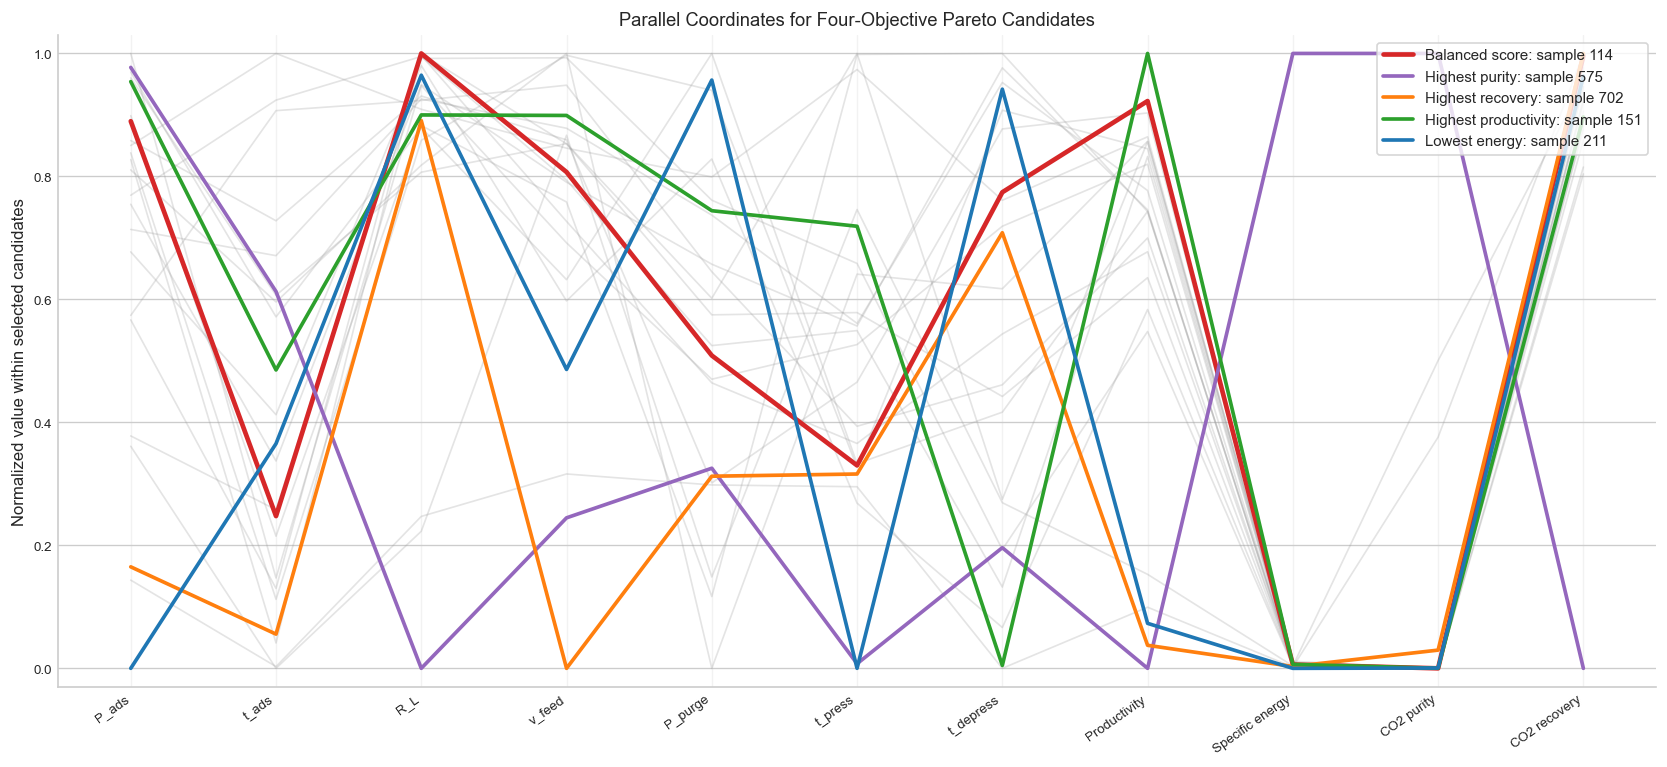

,sample_id,x1,x2,x3,x4,x5,x6,x7,productivity_mol_kg_h,energy_kWh_ton,purity,recovery,balanced_score
113,114,895116.723019,1017.523956,0.996299,0.821628,55950.973967,32.756355,74.499151,106.558100,558.204350,0.150007,0.996355,2.567504
150,151,951662.473321,1972.915066,0.896690,0.899407,76687.992847,69.673719,1.929522,115.449603,582.025840,0.150091,0.897346,2.539883
576,577,789378.725273,3736.556119,0.991350,0.810477,57371.755639,53.568531,13.953667,96.189754,521.305557,0.150005,0.991390,2.481345
232,233,867508.205766,2947.885692,0.927299,0.865859,37710.047229,45.617255,84.208264,104.333454,657.343541,0.150048,0.927657,2.458071
164,165,860355.316094,4041.639681,0.905852,0.854460,81520.381371,93.868120,73.270141,99.874756,533.583845,0.150047,0.906191,2.424728
798,799,991835.868945,612.929106,0.944036,0.724390,52558.067604,51.409134,69.286821,94.762249,618.629195,0.150246,0.945886,2.401545
608,609,740589.659126,2719.933652,0.922551,0.881797,76056.994612,54.677158,91.331902,89.832460,493.150571,0.150063,0.923017,2.364693
198,199,849925.313351,473.558186,0.855613,0.982061,93926.074586,32.465480,87.079778,97.647786,543.547316,0.150692,0.860337,2.358139
941,942,776499.185513,1377.769156,0.945766,0.807723,69028.395643,54.272116,93.572620,86.240827,506.466375,0.150099,0.946512,2.353771
346,347,840388.658507,188.287996,0.992986,0.753891,52034.832199,36.146005,52.760496,78.395591,551.401815,0.150371,0.995709,2.324685


In [ ]:
front = analysis.loc[analysis["is_pareto"]].copy()
if front.empty:
    front = analysis.copy()

selected = front.sort_values("balanced_score", ascending=False).head(20).copy()
representatives = {
    "Balanced score": front.loc[front["balanced_score"].idxmax(), "sample_id"],
    "Highest purity": front.loc[front["purity"].idxmax(), "sample_id"],
    "Highest recovery": front.loc[front["recovery"].idxmax(), "sample_id"],
    "Highest productivity": front.loc[front["productivity_mol_kg_h"].idxmax(), "sample_id"],
    "Lowest energy": front.loc[front["energy_kWh_ton"].idxmin(), "sample_id"],
}

# Ensure highlighted representative samples are included in the plot.
missing_ids = [sid for sid in representatives.values() if sid not in selected["sample_id"].values]
if missing_ids:
    selected = pd.concat([selected, front.loc[front["sample_id"].isin(missing_ids)]], ignore_index=False)
selected = selected.drop_duplicates(subset="sample_id").copy()

parallel_cols = [*design_cols, "productivity_mol_kg_h", "energy_kWh_ton", "purity", "recovery"]
parallel = selected[["sample_id", *parallel_cols, "balanced_score"]].copy()

normalized = pd.DataFrame({"sample_id": parallel["sample_id"]})
for col in parallel_cols:
    normalized[col] = minmax_scale(parallel[col])

fig, ax = plt.subplots(figsize=(14, 6.5))
x_positions = np.arange(len(parallel_cols))

for _, row in normalized.iterrows():
    ax.plot(x_positions, row[parallel_cols], color="#9E9E9E", alpha=0.28, linewidth=1.0)

highlight_styles = {
    "Balanced score": {"color": "#D62728", "linewidth": 2.8},
    "Highest purity": {"color": "#9467BD", "linewidth": 2.2},
    "Highest recovery": {"color": "#FF7F0E", "linewidth": 2.2},
    "Highest productivity": {"color": "#2CA02C", "linewidth": 2.2},
    "Lowest energy": {"color": "#1F77B4", "linewidth": 2.2},
}

for label, sample_id in representatives.items():
    row = normalized.loc[normalized["sample_id"].eq(sample_id)]
    if row.empty:
        continue
    ax.plot(x_positions, row.iloc[0][parallel_cols], label=f"{label}: sample {int(sample_id)}", **highlight_styles[label])

ax.set_xticks(x_positions)
axis_labels = [short_label(col) if col in design_cols else kpi_meta[col]["label"] for col in parallel_cols]
ax.set_xticklabels(axis_labels, rotation=35, ha="right")
ax.set_ylabel("Normalized value within selected candidates")
ax.set_ylim(-0.03, 1.03)
ax.set_title("Parallel Coordinates for Four-Objective Pareto Candidates")
ax.legend(loc="upper right", frameon=True)
ax.grid(axis="x", alpha=0.25)
fig.tight_layout()
save_figure(fig, "07_top_candidates_parallel_coordinates")
plt.show()

selected_summary = selected.sort_values("balanced_score", ascending=False)[[
    "sample_id", *design_cols, "productivity_mol_kg_h", "energy_kWh_ton", "purity", "recovery", "balanced_score"
]].head(20)
selected_summary


## Recommended Use in Report and Slides

- Use **Objective Tradeoff** as the main result figure: it directly shows the four-objective Pareto set projected onto productivity and energy.
- Use **Sampling Coverage** in the method section to demonstrate that the LHS design space was well covered.
- Use **Four Key Output Metric Scatter Matrix** to summarize purity, recovery, productivity, and energy tradeoffs before discussing optimization results.
- Use **Input-Output Correlation Coefficient Distribution** to explain which process variables most strongly affect the four important outputs.
- Use **Sensitivity Panels** as supporting analysis or appendix material because they are information-dense.
- Use **Top Candidate Parallel Coordinates** when explaining why a final operating point was selected from the four-objective Pareto candidates.


In [ ]:
expected_figures = [
    "01_sampling_coverage_histograms",
    "02_lhs_pair_matrix",
    "03_kpi_distributions",
    "04_objective_tradeoff_pareto",
    "05_input_output_correlation_distribution",
    "06_design_variable_sensitivity_panels",
    "07_top_candidates_parallel_coordinates",
]

inventory = []
for stem in expected_figures:
    png_path = PNG_DIR / f"{stem}.png"
    pdf_path = PDF_DIR / f"{stem}.pdf"
    inventory.append({
        "figure": stem,
        "png_exists": png_path.exists(),
        "png_size_bytes": png_path.stat().st_size if png_path.exists() else 0,
        "pdf_exists": pdf_path.exists(),
        "pdf_size_bytes": pdf_path.stat().st_size if pdf_path.exists() else 0,
    })

inventory_df = pd.DataFrame(inventory)
if not inventory_df[["png_exists", "pdf_exists"]].all().all():
    raise FileNotFoundError("One or more expected figure outputs were not created.")
if not (inventory_df[["png_size_bytes", "pdf_size_bytes"]] > 0).all().all():
    raise ValueError("One or more figure outputs are empty.")

inventory_df


,figure,png_exists,png_size_bytes,pdf_exists,pdf_size_bytes
0,01_sampling_coverage_histograms,True,299324,True,26136
1,02_lhs_pair_matrix,True,1958396,True,370098
2,03_kpi_distributions,True,1526713,True,253767
3,04_objective_tradeoff_pareto,True,975909,True,212909
4,05_input_output_correlation_distribution,True,318160,True,54715
5,06_design_variable_sensitivity_panels,True,2426072,True,481624
6,07_top_candidates_parallel_coordinates,True,1490783,True,21383
